# Experiment 5 — kNN graph sensitivity (n_neighbors × distance metric)

Confirmatory sensitivity analysis for the reviewer question on kNN graph density
and construction. Sweeps `n_neighbors in {10, 50, 100}` and
`metric in {euclidean, cosine}` for the GE-MolSG geo WKS descriptor, evaluated
by leave-one-out retrieval (BEDROC α=20, EF1%) on a fixed subset of DUDE-Z targets.

**This is an approximation of the original optimisation protocol described in the
manuscript, not a literal re-run**: the original list of 10 targets / 20 sampled
actives per target (Table 5) was not found anywhere in this repository, so both
are re-selected here reproducibly with a fixed seed.

Each `n_neighbors` value uses its own codebook (`codebooks/gemolsg_cb_<k>.npy`,
built by `codebook_bootstrap.py` from the same 400-surface sample set as the
original `ge_molsg_cb.npy`, varying only `n_neighbors`) rather than one fixed
codebook — this removes the earlier confound of evaluating non-default kNN
settings against a codebook trained only at `n_neighbors=100`. The cosine
ablation reuses the same per-k codebook (trained with the Euclidean backend);
no separate cosine-trained codebook was built, since cosine is an
experiment-only variant, not part of the library or the original recipe.

Cosine distance is not implemented anywhere in `ge_molsg` (both neighbor
backends hardcode Euclidean); it is added here only as a local, experiment-only
kNN backend passed as a plain callable — `ge_molsg.compute_affinity` already
accepts any `(points, k) -> (indices, distances)` callable as its `backend`,
so no changes to the library are needed.

### Inputs

```

<DATA_ROOT>/DUDE-Z/<TARGET>.tar.gz -> <TARGET>/ESP_Npy/{ligand,decoy}_<ID>.npy```

experiments/codebooks/gemolsg_cb_{10,50,100}.npy   (per-n_neighbors GE-MolSG codebooks)<QUERIES_DIR>/<target>.csv                   (column 'query' or 'queries')

## 1 · Configuration

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import logging, sys, tarfile
from pathlib import Path
import numpy as np
import pandas as pd

# Directory holding the bundled experiment modules (exp3_methods.py). Set
# EXP_DIR explicitly if you run this notebook from elsewhere; by default it
# searches the CWD and its scripts/experiments subdir, then walks up parents.
EXP_DIR = None  # e.g. Path("/abs/path/to/repo/scripts/experiments")
def _find_exp_dir(explicit):
    if explicit is not None:
        return Path(explicit).resolve()
    here = Path.cwd().resolve()
    cands = [here / "scripts" / "experiments", here]
    cands += [p / "scripts" / "experiments" for p in here.parents]
    cands += [here / "experiments"]
    for cand in cands:
        if (cand / "exp3_methods.py").exists():
            return cand.resolve()
    raise FileNotFoundError(
        "Could not locate exp3_methods.py. Set EXP_DIR to scripts/experiments.")
EXP_DIR = _find_exp_dir(EXP_DIR)
sys.path.insert(0, str(EXP_DIR))   # bundled: exp3_methods

# Full DUDE-Z target list (same as experiments 1-4); 10 are sampled below.
ALL_TARGETS = [
    "AA2AR", "ABL1", "ACES", "ADA", "ADRB2", "AMPC", "ANDR", "CSF1R",
    "CXCR4", "DEF", "DRD4", "EGFR", "FA10", "FA7", "FABP4", "FGFR1",
    "FKB1A", "GLCM", "HDAC8", "HIVPR", "HMDH", "HS90A", "ITAL", "KIT",
    "KITH", "LCK", "MAPK2", "MK01", "MT1", "NRAM", "PARP1", "PLK1",
    "PPARA", "PTN1", "PUR2", "RENI", "ROCK1", "SRC", "THRB", "TRY1",
    "TRYB1", "UROK", "XIAP",
]

# Data: per-target archives <TARGET>.tar.gz are hosted in one Zenodo record;
# only the targets actually selected below are fetched.
ZENODO_BASE_URL = "https://zenodo.org/records/20547837/files"
DATA_ROOT    = Path("dude_z_data")   # local cache for downloaded/extracted targets
QUERIES_DIR  = Path("queries")
OUT_DIR      = Path("experiments_out/exp5_knn_metric_sensitivity")
PERSISTENT_OUT_DIR = Path("results/exp5_knn_metric_sensitivity")
CODEBOOK_DIR = Path("codebooks")
# One codebook per n_neighbors (built by codebook_bootstrap.py); reused for
# both metrics at that n_neighbors, since only Euclidean-trained codebooks exist.
CODEBOOK_PATHS = {k: CODEBOOK_DIR / f"gemolsg_cb_{k}.npy" for k in [10, 50, 100]}

# Shared geo / WKS params (same values used everywhere else in the paper,
# except n_neighbors and the distance metric, which are swept below).
N_COMPONENTS, EVALS, VAR, EW, LAP_NORM, BOF_KNN = 100, 100, 15, 0.3, "normalized", 3

# Sweep grid
SWEEP_N_NEIGHBORS = [10, 50, 100]
SWEEP_METRICS = ["euclidean", "cosine"]

# Per-surface encoding (kNN graph + eigensolve) is CPU-bound and embarrassingly
# parallel across surfaces; -1 uses all available cores (this machine: 256).
N_JOBS = -1

# Selection protocol (seeded approximation of the manuscript's Table 5 setup:
# the original 10-target / 20-active selection was not found in this repo)
SEED = 42
N_TARGETS = 10
N_QUERIES_PER_TARGET = 20

FORCE = False  # set True to recompute and overwrite cached per-target results

In [2]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT = OUT_DIR / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout), logging.FileHandler(OUT_DIR / "exp5.log")],
    force=True)
log = logging.getLogger("exp5")
log.info("Experiment 5 — kNN sensitivity sweep: n_neighbors=%s, metrics=%s",
          SWEEP_N_NEIGHBORS, SWEEP_METRICS)

02:03:00 [INFO] Experiment 5 — kNN sensitivity sweep: n_neighbors=[10, 50, 100], metrics=['euclidean', 'cosine']


## 2 · Data / query helpers

Same helpers as experiments 1-4 (data download/extraction, query CSV loading).

In [3]:
import subprocess
import urllib.request


def fetch_target(target, data_root):
    """Ensure <data_root>/<TARGET>/ exists, downloading from Zenodo if needed.

    Returns the ``<TARGET>/`` directory.
    """
    data_root = Path(data_root)
    for cand in (data_root / target, data_root / target.upper(),
                 data_root / "DUDE-Z" / target):
        if (cand / "ESP_Npy").is_dir():
            return cand

    local_tar = None
    for tar in (data_root / f"{target}.tar.gz",
                data_root / "DUDE-Z" / f"{target}.tar.gz"):
        if tar.exists():
            local_tar = tar
            break

    def _download(dest):
        if not ZENODO_BASE_URL:
            raise FileNotFoundError(
                f"No local data for '{target}' and ZENODO_BASE_URL is not set.")
        dest.parent.mkdir(parents=True, exist_ok=True)
        url = f"{ZENODO_BASE_URL.rstrip('/')}/{target}.tar.gz"
        log.info("Downloading %s", url)
        try:
            subprocess.run(["curl", "-fSL", "-o", str(dest), url], check=True)
        except (FileNotFoundError, subprocess.CalledProcessError):
            urllib.request.urlretrieve(url, dest)

    if local_tar is None:
        local_tar = data_root / f"{target}.tar.gz"
        _download(local_tar)

    # A tar.gz left over from an interrupted download extracts as truncated;
    # detect that, drop the bad cache file, and re-download once before failing.
    for attempt in range(2):
        try:
            log.info("Extracting %s", local_tar)
            with tarfile.open(local_tar, "r:gz") as tf:
                tf.extractall(data_root)
            break
        except (tarfile.TarError, EOFError, OSError) as exc:
            if attempt == 0:
                log.warning("Corrupt/incomplete archive %s (%s); re-downloading", local_tar, exc)
                local_tar.unlink(missing_ok=True)
                _download(local_tar)
            else:
                raise

    for cand in (data_root / target, data_root / target.upper()):
        if (cand / "ESP_Npy").is_dir():
            return cand
    hits = list(data_root.rglob(f"{target}/ESP_Npy")) or list(data_root.rglob("ESP_Npy"))
    if hits:
        return hits[0].parent
    raise FileNotFoundError(f"Extracted '{target}' but found no ESP_Npy under {data_root}")


def resolve_target_dir(target, data_root):
    target_root = fetch_target(target, data_root)
    esp_dir = target_root / "ESP_Npy"
    if not esp_dir.is_dir():
        raise FileNotFoundError(f"No ESP_Npy for '{target}' under {target_root}")
    return esp_dir


def resolve_queries_csv(queries_dir, target):
    for name in (f"{target}.csv", f"{target.lower()}.csv", f"{target.upper()}.csv"):
        if (queries_dir / name).exists():
            return queries_dir / name
    raise FileNotFoundError(f"No queries CSV for '{target}' under {queries_dir}")


def load_query_ids(csv_path):
    df = pd.read_csv(csv_path)
    col = next((c for c in ("queries", "query") if c in df.columns), None)
    if col is None:
        col = df.columns[0] if df.shape[1] == 1 else None
    if col is None:
        raise ValueError(f"{csv_path}: no 'query'/'queries' column found")
    return [str(q).strip() for q in df[col].dropna()]


def list_surface_fns(surf_dir):
    return sorted([f for f in os.listdir(surf_dir) if f.endswith(".npy")], reverse=True)

## 3 · Target and query selection

Seeded, reproducible stand-in for the manuscript's "10 DUDE-Z targets, 20
randomly selected actives per target" — see the note at the top of this
notebook.

In [4]:
rng = np.random.default_rng(SEED)

SELECTED_TARGETS = sorted(rng.choice(ALL_TARGETS, size=N_TARGETS, replace=False).tolist())
log.info("Selected %d/%d targets: %s", len(SELECTED_TARGETS), len(ALL_TARGETS), SELECTED_TARGETS)

SELECTED_QUERIES = {}  # target -> list of query ids (<= N_QUERIES_PER_TARGET)
for target in SELECTED_TARGETS:
    csv_path = resolve_queries_csv(QUERIES_DIR, target)
    all_ids = load_query_ids(csv_path)
    n = min(N_QUERIES_PER_TARGET, len(all_ids))
    if n < N_QUERIES_PER_TARGET:
        log.warning("%s: only %d actives available (< %d requested)", target, len(all_ids), N_QUERIES_PER_TARGET)
    idx = rng.choice(len(all_ids), size=n, replace=False)
    SELECTED_QUERIES[target] = [all_ids[i] for i in sorted(idx.tolist())]
    log.info("%s: sampled %d/%d query actives", target, n, len(all_ids))

02:03:00 [INFO] Selected 10/43 targets: ['ADA', 'ADRB2', 'CXCR4', 'FKB1A', 'KIT', 'MK01', 'MT1', 'PTN1', 'SRC', 'TRY1']
02:03:00 [INFO] ADA: sampled 20/20 query actives
02:03:00 [INFO] ADRB2: sampled 20/20 query actives
02:03:00 [INFO] CXCR4: sampled 20/20 query actives
02:03:00 [INFO] FKB1A: sampled 20/20 query actives
02:03:00 [INFO] KIT: sampled 20/20 query actives
02:03:00 [INFO] MK01: sampled 20/20 query actives
02:03:00 [INFO] MT1: sampled 20/20 query actives
02:03:00 [INFO] PTN1: sampled 20/20 query actives
02:03:00 [INFO] SRC: sampled 20/20 query actives
02:03:00 [INFO] TRY1: sampled 20/20 query actives


## 4 · Retrieval metrics (BEDROC α=20, EF1%)

In [5]:
from rdkit.ML.Scoring import Scoring


def _metrics_from_sim(sim, labels_rest):
    order = np.argsort(sim)[::-1]
    scores = np.column_stack([np.asarray(sim)[order], np.asarray(labels_rest)[order]])
    ef = Scoring.CalcEnrichment(scores, 1, [0.01])
    bedroc = Scoring.CalcBEDROC(scores, 1, 20)
    return {"EF1%": float(ef[0]), "BEDROC": float(bedroc)}


def retrieve_simfn(sim_matrix, fns, query_ids):
    """Leave-one-out retrieval metrics for each query id against the rest of fns."""
    labels = np.asarray([1 if f[0] == "l" else 0 for f in fns])
    stems = [f[:-6] if f.endswith(".npy") else f.rsplit(".", 1)[0] for f in fns]
    rows = []
    for qid in query_ids:
        hits = [j for j, s in enumerate(stems) if s == qid or s.endswith(qid)]
        if not hits:
            log.warning("  query '%s' not found; skipping", qid); continue
        i = hits[0]
        keep = np.arange(sim_matrix.shape[0]) != i
        rest = labels[keep]
        sim = sim_matrix[i][keep]
        m = _metrics_from_sim(sim, rest); m["RefMol"] = stems[i]; rows.append(m)
    return pd.DataFrame(rows, columns=["RefMol", "EF1%", "BEDROC"])

02:03:00 [INFO] Enabling RDKit 2023.09.6 jupyter extensions


## 5 · kNN backends (Euclidean = library default, Cosine = local experiment-only helper)

In [6]:
import ge_molsg as gm


def cosine_backend(points, k):
    """(points, k) -> (indices, distances), matching gm.neighbors.NeighborBackend."""
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k, metric="cosine")
    nn.fit(points)
    dist, idx = nn.kneighbors(points)
    return idx, dist


# gm.compute_affinity's `backend` accepts a registered name or any callable
# matching the NeighborBackend protocol, so cosine needs no library changes.
METRIC_BACKENDS = {"euclidean": "ckdtree", "cosine": cosine_backend}

## 6 · Descriptor / encoder

Mirrors `exp3_methods.geo_wks_ge`, but with `n_neighbors` and `backend`
parameterised for the sweep (that helper hardcodes `backend="ckdtree"`, so it
can't be reused directly here).

In [7]:
from sklearn.metrics.pairwise import chi2_kernel
from joblib import Parallel, delayed
import exp3_methods as M

CODEBOOKS = {k: np.load(path, allow_pickle=True) for k, path in CODEBOOK_PATHS.items()}


def geo_wks_sweep(graph_features, n_neighbors, backend):
    W = gm.compute_affinity(
        graph_features, n_neighbors=n_neighbors, backend=backend,
        adaptive_bw=True, square_distances=False,
    )
    L = gm.graph_laplacian(W, laplacian_type=LAP_NORM)
    eigensystem = gm.compute_eigenpairs(
        L, n_components=N_COMPONENTS, drop_first=True, eigensolver="arpack",
    )
    return gm.wks(eigensystem, evals=EVALS, variance=VAR, l2=True)


def _encode_one_surface(esp_dir, f, n_neighbors, backend):
    """One surface -> BoF vector. Runs in a worker process (see encode_target)."""
    mol = np.load(str(Path(esp_dir) / f), allow_pickle=True)
    coords, esp = mol[0], mol[2]
    feat = np.concatenate([coords, (esp * EW).reshape(-1, 1)], axis=1)
    wks = np.nan_to_num(geo_wks_sweep(feat, n_neighbors, backend))
    return M.knn_histogram(wks, CODEBOOKS[n_neighbors], knn=BOF_KNN)


def encode_target(esp_dir, fns, n_neighbors, backend, n_jobs=N_JOBS):
    """All surfaces for one target -> (BoF matrix, chi2 similarity matrix)."""
    vecs = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_encode_one_surface)(esp_dir, f, n_neighbors, backend) for f in fns
    )
    V = np.asarray(vecs)
    return V, chi2_kernel(V)

## 7 · Sweep

Iterates `n_neighbors × metric` over the selected targets, with per-target,
per-config results cached to disk so a partial/interrupted run can resume
(set `FORCE = True` above to recompute).

In [8]:
per_query_rows = []  # one row per (target, n_neighbors, metric, query)

for target in SELECTED_TARGETS:
    esp_dir = resolve_target_dir(target, DATA_ROOT)
    fns = list_surface_fns(esp_dir)
    query_ids = SELECTED_QUERIES[target]

    for n_neighbors in SWEEP_N_NEIGHBORS:
        for metric in SWEEP_METRICS:
            cache_path = RESULTS_ROOT / f"{target}_knn{n_neighbors}_{metric}.csv"
            if cache_path.exists() and not FORCE:
                df = pd.read_csv(cache_path)
            else:
                log.info("Encoding %s (n_neighbors=%d, metric=%s, %d surfaces)",
                          target, n_neighbors, metric, len(fns))
                _, sim_matrix = encode_target(esp_dir, fns, n_neighbors, METRIC_BACKENDS[metric])
                df = retrieve_simfn(sim_matrix, fns, query_ids)
                df.to_csv(cache_path, index=False)
            df = df.assign(Target=target, n_neighbors=n_neighbors, metric=metric)
            per_query_rows.append(df)

per_query = pd.concat(per_query_rows, ignore_index=True)
per_query.to_csv(PERSISTENT_OUT_DIR / "per_query_results.csv", index=False)
log.info("Sweep complete: %d per-query rows", len(per_query))

02:03:01 [INFO] Sweep complete: 1200 per-query rows


## 8 · Aggregation and reporting

In [9]:
# Per-target mean first (so every target contributes equally), then mean/std across targets.
per_target = (per_query.groupby(["n_neighbors", "metric", "Target"])[["EF1%", "BEDROC"]]
              .mean().reset_index())

summary = (per_target.groupby(["n_neighbors", "metric"])
           .agg(mean_BEDROC=("BEDROC", "mean"), std_BEDROC=("BEDROC", "std"),
                mean_EF1=("EF1%", "mean"), std_EF1=("EF1%", "std"),
                n_targets=("Target", "nunique"))
           .reset_index()
           .sort_values("mean_BEDROC", ascending=False)
           .reset_index(drop=True))
summary.to_csv(PERSISTENT_OUT_DIR / "summary.csv", index=False)

best = summary.iloc[0]
log.info("Best config by mean BEDROC: n_neighbors=%s, metric=%s (BEDROC=%.4f, EF1%%=%.2f)",
          best["n_neighbors"], best["metric"], best["mean_BEDROC"], best["mean_EF1"])
summary

02:03:01 [INFO] Best config by mean BEDROC: n_neighbors=100, metric=euclidean (BEDROC=0.2825, EF1%=12.98)


,n_neighbors,metric,mean_BEDROC,std_BEDROC,mean_EF1,std_EF1,n_targets
0,100,euclidean,0.282494,0.112442,12.977251,6.420974,10
1,50,euclidean,0.282048,0.112791,13.142268,6.707980,10
2,10,euclidean,0.267140,0.108651,12.031865,6.259203,10
3,50,cosine,0.218203,0.077901,8.666027,4.848941,10
4,10,cosine,0.217776,0.078280,8.650327,4.671841,10
5,100,cosine,0.212177,0.076044,8.412742,4.847506,10


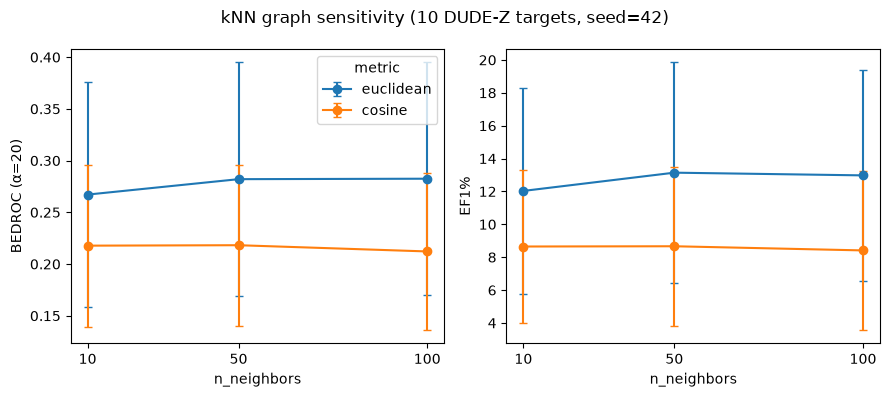

02:03:01 [INFO] saved results/exp5_knn_metric_sensitivity/sensitivity.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 4), facecolor="white")
for ax, metric_col, ylabel in zip(axes, ["mean_BEDROC", "mean_EF1"], ["BEDROC (α=20)", "EF1%"]):
    for metric in SWEEP_METRICS:
        sub = summary[summary["metric"] == metric].sort_values("n_neighbors")
        ax.errorbar(sub["n_neighbors"], sub[metric_col],
                    yerr=sub[metric_col.replace("mean_", "std_")],
                    marker="o", capsize=3, label=metric)
    ax.set_xlabel("n_neighbors"); ax.set_ylabel(ylabel)
    ax.set_xticks(SWEEP_N_NEIGHBORS)
axes[0].legend(title="metric")
fig.suptitle(f"kNN graph sensitivity ({len(SELECTED_TARGETS)} DUDE-Z targets, seed={SEED})")
plt.tight_layout()
path = PERSISTENT_OUT_DIR / "sensitivity.png"
plt.savefig(path, dpi=150, bbox_inches="tight"); plt.show()
log.info("saved %s", path)